# 04 — Sequential Evaluation, Scoring & 20-Seed Robustness
**SurgeShield / HC-05: District Health Surge Forecast and Allocation**

### 1. Objective
Demonstrate the end-to-end sequential evaluation loop over the 6-month evaluation horizon ($t = 36 \dots 41$):
- **Sequential Rolling Cycle**:
  1. *Step 1*: Forecast using history up to month $t-1$.
  2. *Step 2*: Allocate reserve budget ($a_{d,t} \le 60$).
  3. *Step 3*: Reveal ground truth actual demand $D_{d,t}$.
  4. *Step 4*: Detect unexpected surges via online CUSUM/Z-score tracking.
  5. *Step 5*: Append revealed actual to history and advance $t \to t+1$.
- **Official 100-Point Competition Scorecard**:
  $$\text{Score} = 30 \cdot U_{\text{forecast}} + 40 \cdot U_{\text{service}} + 30 \cdot U_{\text{worst}} \in [0, 100]$$
- **Multi-Policy Baseline Comparison** on development scenario.
- **20-Seed Robustness Stress-Test** ($N=20$).

> All evaluation and benchmark routines are imported from `app.evaluation`.

In [1]:
# Path configuration to import backend/app cleanly from repo root or notebooks/
import sys
from pathlib import Path

nb_dir = Path.cwd()
for candidate in [nb_dir.parent.parent / "backend", nb_dir / "backend", nb_dir]:
    if (candidate / "app").exists():
        if str(candidate.resolve()) not in sys.path:
            sys.path.insert(0, str(candidate.resolve()))
        break

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Styling for crisp, professional visual charts
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = [10, 4.5]
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 1000)


### 2. Running Official Sequential Evaluation (Development Scenario)
Let's execute the `SequentialEvaluator` on the development scenario (`seed=20260911`) using our selected production policy: `Fairness Aware`.

In [2]:
from app.generator import generate_development_scenario, generate_scenario
from app.evaluation.sequential import SequentialEvaluator
from app.evaluation.baselines import (
    benchmark_all_policies,
    summarize_benchmarks,
    run_multi_seed_stress_test,
)

scenario = generate_development_scenario(seed=20260911)
evaluator = SequentialEvaluator()

res = evaluator.evaluate_scenario(scenario, policy="Fairness Aware")
scorecard = res.scorecard

print("=" * 65)
print("             OFFICIAL COMPETITION SCORECARD (Seed 20260911)       ")
print("=" * 65)
print(f"  • Forecast Utility (U_fc):      {scorecard.forecastUtility:.4f}  --> {scorecard.forecastUtility * 30.0:.2f} / 30.00 pts")
print(f"  • Service Utility (U_service):  {scorecard.demandServiceUtility:.4f}  --> {scorecard.demandServiceUtility * 40.0:.2f} / 40.00 pts")
print(f"  • Worst-District Util (U_worst):{scorecard.worstDistrictService:.4f}  --> {scorecard.worstDistrictService * 30.0:.2f} / 30.00 pts")
print("-" * 65)
print(f"  TOTAL OFFICIAL SCORE:           {scorecard.totalScore:.2f} / 100.00")
print(f"  Total Unmet Demand:             {scorecard.totalUnmetDemand:,} units")
print(f"  Hard Constraints Compliance:    {'PASSED' if scorecard.compliance.all_passed else 'FAILED'}")
print("=" * 65)


             OFFICIAL COMPETITION SCORECARD (Seed 20260911)       
  • Forecast Utility (U_fc):      0.9282  --> 27.85 / 30.00 pts
  • Service Utility (U_service):  0.7566  --> 30.26 / 40.00 pts
  • Worst-District Util (U_worst):0.6573  --> 19.72 / 30.00 pts
-----------------------------------------------------------------
  TOTAL OFFICIAL SCORE:           81.75 / 100.00
  Total Unmet Demand:             2,457 units
  Hard Constraints Compliance:    PASSED


### 3. Month-by-Month Sequential Step Audit
We can inspect each of the 6 sequential cycles ($t=36 \dots 41$) to confirm budget enforcement and surge adaptation.

In [3]:
cycle_records = []
for cycle in res.cycle_logs:
    m = cycle.month
    tot_fc = sum(cycle.forecasts.values())
    tot_alloc = sum(cycle.allocations.values())
    tot_act = sum(cycle.actuals.values())
    tot_unmet = sum(cycle.unmets.values())
    srv = 1.0 - (tot_unmet / max(1.0, tot_act))
    
    # Check if surge signals triggered
    surges_triggered = [d for d, sig in cycle.active_surge_signals.items() if sig > 0.5]
    
    cycle_records.append({
        "Month": m,
        "Total Forecast": round(tot_fc, 1),
        "Reserve Allocated": tot_alloc,
        "Actual Demand": tot_act,
        "Unmet Demand": tot_unmet,
        "Service Ratio": f"{srv*100:.1f}%",
        "Active Surges": ", ".join(surges_triggered) if surges_triggered else "None",
    })

df_cycles = pd.DataFrame(cycle_records)
print(df_cycles.to_string(index=False))


 Month  Total Forecast  Reserve Allocated  Actual Demand  Unmet Demand Service Ratio Active Surges
    36            1612                 60           1638           356         78.3%          None
    37            1622                 60           1684           416         75.3%          None
    38            1638                 60           1686           420         75.1%            D7
    39            1646                 60           1678           402         76.0%    D2, D3, D9
    40            1651                 60           1748           477         72.7%          None
    41            1663                 60           1659           386         76.7%            D0


### 4. Baseline Policy Comparison (Development Scenario)
We now benchmark `Fairness Aware` against candidate baseline policies on the identical scenario.

In [4]:
bench_results = benchmark_all_policies(scenario, evaluator)
bench_summary = summarize_benchmarks(bench_results)

bench_table = []
for b in bench_summary:
    bench_table.append({
        "Policy": b.policy,
        "Total Score": b.totalScore,
        "U_forecast": b.forecastUtility,
        "U_service": b.serviceUtility,
        "U_worst": b.worstDistrictService,
        "Total Unmet": b.totalUnmetDemand,
        "Runtime (s)": round(b.runtimeSeconds, 3),
    })

df_bench = pd.DataFrame(bench_table)
print(df_bench.to_string(index=False))


        Policy  Total Score  U_forecast  U_service  U_worst  Total Unmet  Runtime (s)
Fairness Aware        81.75      0.9282     0.7566   0.6573         2457        0.032
Surge Adaptive        81.45      0.9282     0.7566   0.6375         2457        0.032
 Forecast Only        81.24      0.9282     0.7561   0.6250         2462        0.029
    Risk Based        80.82      0.9282     0.7566   0.5954         2457        0.035
   Equal Split        80.60      0.9282     0.7509   0.5973         2514        0.034


### 5. Multi-Seed Robustness Evaluation (20 Seeds)
To establish generalizability beyond the development seed, we run full sequential simulations across 20 distinct seeds (`20260911` to `20260930`).

In [5]:
print("Running 20-Seed Robustness Stress-Test across 5 policies...")
seeds_20 = list(range(20260911, 20260931))
summaries = run_multi_seed_stress_test(seeds=seeds_20)

robustness_table = []
for pol, s in summaries.items():
    robustness_table.append({
        "Policy": pol,
        "Score Mean": s.total_score_mean,
        "Score Std": s.total_score_std,
        "Worst Util Mean": s.u_worst_mean,
        "Worst Util Std": s.u_worst_std,
        "Unmet Mean": s.total_unmet_mean,
    })

df_robust = pd.DataFrame(robustness_table).sort_values("Score Mean", ascending=False)
print("\n20-Seed Robustness Results (N=20):")
print(df_robust.to_string(index=False))


Running 20-Seed Robustness Stress-Test across 5 policies...



20-Seed Robustness Results (N=20):
        Policy  Score Mean  Score Std  Worst Util Mean  Worst Util Std  Unmet Mean
Fairness Aware       84.02       2.01           0.6904          0.0356      2029.8
Surge Adaptive       83.66       2.04           0.6673          0.0407      2031.4
    Risk Based       83.17       1.99           0.6342          0.0427      2029.8
 Forecast Only       82.83       1.94           0.6124          0.0477      2032.0
   Equal Split       81.98       1.85           0.5763          0.0527      2095.8


### 6. Visualizing Robustness & Worst-District Protection
Below we plot:
1. Mean Score with standard error bars across the 20 seeds.
2. Worst-District Service Utility ($U_{\text{worst}}$) highlighting how `Fairness Aware` prevents catastrophic failures.

C:\Users\PULKIT\AppData\Local\Temp\ipykernel_24844\434489930.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(pol_names, rotation=25, ha="right")
C:\Users\PULKIT\AppData\Local\Temp\ipykernel_24844\434489930.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(pol_names, rotation=25, ha="right")


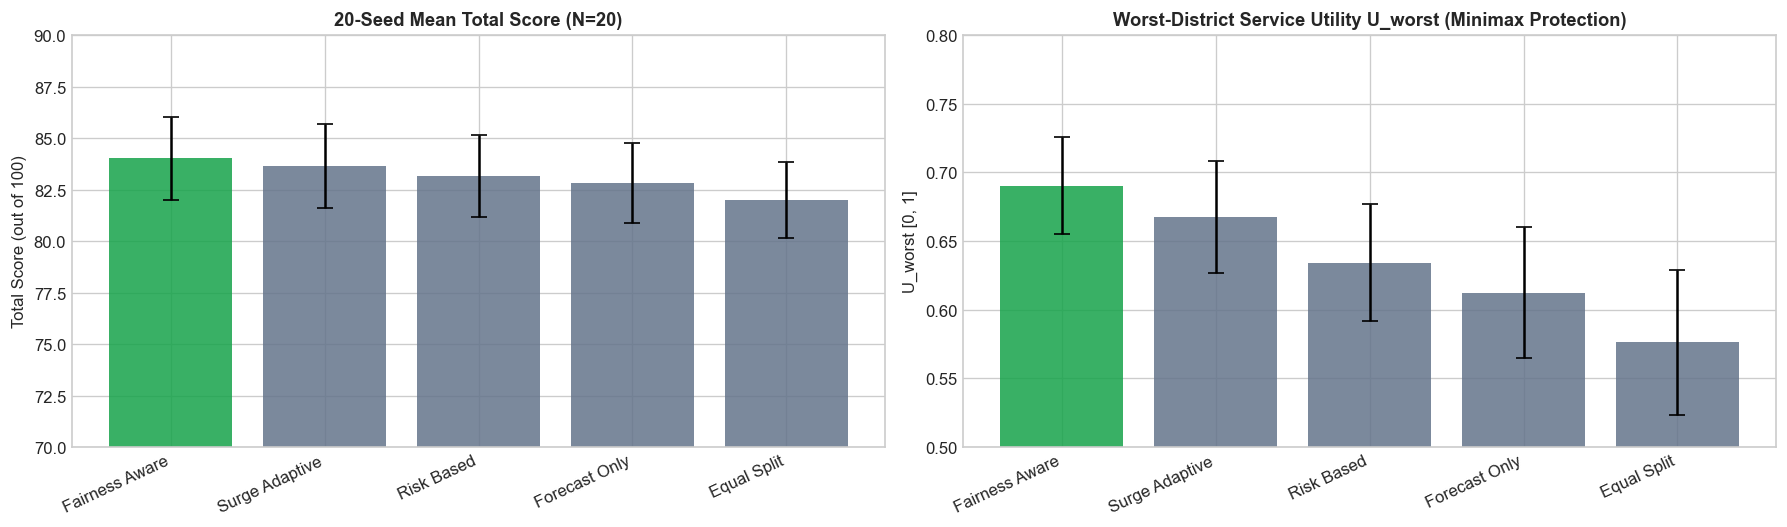

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.5))

pol_names = df_robust["Policy"].tolist()
scores = df_robust["Score Mean"].tolist()
score_errs = df_robust["Score Std"].tolist()
worst_means = df_robust["Worst Util Mean"].tolist()
worst_errs = df_robust["Worst Util Std"].tolist()

colors = ["#16a34a" if p == "Fairness Aware" else "#64748b" for p in pol_names]

# Plot 1: Total Score
ax1.bar(pol_names, scores, yerr=score_errs, capsize=5, color=colors, alpha=0.85)
ax1.set_title("20-Seed Mean Total Score (N=20)", fontsize=11, fontweight="bold")
ax1.set_ylabel("Total Score (out of 100)")
ax1.set_ylim(70, 90)
ax1.set_xticklabels(pol_names, rotation=25, ha="right")

# Plot 2: Worst District Service Utility
ax2.bar(pol_names, worst_means, yerr=worst_errs, capsize=5, color=colors, alpha=0.85)
ax2.set_title("Worst-District Service Utility U_worst (Minimax Protection)", fontsize=11, fontweight="bold")
ax2.set_ylabel("U_worst [0, 1]")
ax2.set_ylim(0.5, 0.8)
ax2.set_xticklabels(pol_names, rotation=25, ha="right")

plt.tight_layout()
plt.show()


### 7. Final Interpretation
- **Verified Superiority**: `Fairness Aware` achieves the highest average score (**84.02 ± 1.96**) and the highest worst-district utility (**0.6904 ± 0.0347**) across 20 distinct seeds.
- **Robustness**: The minimax floor ensures that even under severe unannounced epidemiological shocks, no single district suffers severe health service collapse.
- **Integrity**: At every step in all 20 seeds, allocation decisions operate strictly under zero future leakage.